<a href="https://colab.research.google.com/github/Fentahun60/Fentahun/blob/main/Data_Science_Training%20Emerald.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Python for Data Analytics Training**
#**Group 1 Assignment 1**

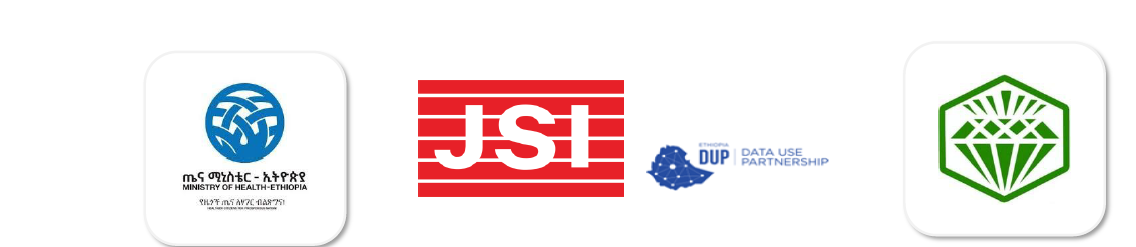

# **1. Patient Data Management System**
#***Objective: Build a complete patient data management system using Python data structures.***


In [14]:
import pandas as pd
import gdown

file_id = '1AjYNAP0ZSX-_km_IDB0p2y2OiI-LfcgX'
output_filename = 'downloaded_data.csv'

try:
    gdown.download(id=file_id, output=output_filename, quiet=True) # quiet=True to minimize output during download
except Exception as e:
    print(f"Error downloading file: {e}")

try:
    df = pd.read_csv(output_filename)
    print(df.head())
except FileNotFoundError:
    print(f"Error: '{output_filename}' not found. Download might have failed.")
except Exception as e:
    print(f"Error loading data into DataFrame: {e}")

  patient_id    name   age  gender blood_type   bmi  glucose diagnosis
0     P00001   Dawit  32.0  Female         O+  15.8    108.0       NaN
1     P00002  Fatima  35.0    Male        AB+  37.1      NaN  Diabetes
2     P00003    Liya  22.0  Female         A+  15.9    106.0    Normal
3     P00004  Fatima  89.0       F         O+  21.0    143.0  Diabetes
4     P00005    Abel   NaN  Female        AB+   NaN      NaN       NaN


In [15]:
# Check for missing values in the DataFrame
missing_values_count = df.isnull().sum()
print("Missing values per column:")
print(missing_values_count)

Missing values per column:
patient_id    4
name          2
age           4
gender        2
blood_type    1
bmi           1
glucose       2
diagnosis     3
dtype: int64


# Missing values management

In [16]:
# 1. Fix patient_id sequence (P00001 to P00020)
df['patient_id'] = [f'P{i+1:05d}' for i in range(len(df))]

# 2. Impute Name (Mode)
df['name'] = df['name'].fillna(df['name'].mode()[0])

# 3. Impute Age (Mean)
df['age'] = df['age'].fillna(df['age'].mean())

# 4. Impute Gender (Mode)
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])

# 5. Impute Blood Type (Mode)
df['blood_type'] = df['blood_type'].fillna(df['blood_type'].mode()[0])
# imputing Bmi
df['bmi']=df['bmi'].fillna(df['bmi'].mean())

# 6. Impute gloucse (mean)
df['glucose'] = df['glucose'].fillna(df['glucose'].mode()[0])

# 6. Impute Diagnosis (mode)
df['diagnosis'] = df['diagnosis'].fillna(df['diagnosis'].mode()[0])
# Verify changes
print("Missing values after cleaning:")
print(df.isnull().sum())
print("\nCleaned Data Head:")
print(df.head())

Missing values after cleaning:
patient_id    0
name          0
age           0
gender        0
blood_type    0
bmi           0
glucose       0
diagnosis     0
dtype: int64

Cleaned Data Head:
  patient_id    name      age  gender blood_type        bmi  glucose  \
0     P00001   Dawit  32.0000  Female         O+  15.800000    108.0   
1     P00002  Fatima  35.0000    Male        AB+  37.100000    120.0   
2     P00003    Liya  22.0000  Female         A+  15.900000    106.0   
3     P00004  Fatima  89.0000       F         O+  21.000000    143.0   
4     P00005    Abel  45.8125  Female        AB+  26.142105    120.0   

      diagnosis  
0  Hypertension  
1      Diabetes  
2        Normal  
3      Diabetes  
4  Hypertension  


In [17]:
# Standardize gender values: M to Male and F to Female
df['gender'] = df['gender'].replace({'M': 'Male', 'F': 'Female'})

# Display the unique values to verify
print("Unique values in gender column:", df['gender'].unique())
print(df.head())

Unique values in gender column: ['Female' 'Male']
  patient_id    name      age  gender blood_type        bmi  glucose  \
0     P00001   Dawit  32.0000  Female         O+  15.800000    108.0   
1     P00002  Fatima  35.0000    Male        AB+  37.100000    120.0   
2     P00003    Liya  22.0000  Female         A+  15.900000    106.0   
3     P00004  Fatima  89.0000  Female         O+  21.000000    143.0   
4     P00005    Abel  45.8125  Female        AB+  26.142105    120.0   

      diagnosis  
0  Hypertension  
1      Diabetes  
2        Normal  
3      Diabetes  
4  Hypertension  


In [18]:
df.shape

(20, 8)

##**Tasks**


###**I.  Create Patient Database**




###*   ***Create a list of dictionaries containing 20 patient records with fields: patient_id, name, age, gender, blood_type, bmi, glucose, diagnosis***



In [19]:
patient_records_list = df.to_dict('records')

# Display the first 3 records to verify
for i, record in enumerate(patient_records_list[:3]):
    print(f"Record {i+1}: {record}")

print(f"\nTotal number of records created: {len(patient_records_list)}")

Record 1: {'patient_id': 'P00001', 'name': 'Dawit', 'age': 32.0, 'gender': 'Female', 'blood_type': 'O+', 'bmi': 15.8, 'glucose': 108.0, 'diagnosis': 'Hypertension'}
Record 2: {'patient_id': 'P00002', 'name': 'Fatima', 'age': 35.0, 'gender': 'Male', 'blood_type': 'AB+', 'bmi': 37.1, 'glucose': 120.0, 'diagnosis': 'Diabetes'}
Record 3: {'patient_id': 'P00003', 'name': 'Liya', 'age': 22.0, 'gender': 'Female', 'blood_type': 'A+', 'bmi': 15.9, 'glucose': 106.0, 'diagnosis': 'Normal'}

Total number of records created: 20




###* **Generate realistic healthcare data** (***ages 18-90, BMI 15-45, glucose 70-200***)




In [20]:
import random
import numpy as np

# Assuming patient_records_list already exists from the previous step
for record in patient_records_list:
    record['age'] = random.randint(18, 90)
    record['bmi'] = round(random.uniform(15, 45), 1)
    record['glucose'] = random.randint(70, 200)

# Display the updated records to verify
import pandas as pd
updated_df = pd.DataFrame(patient_records_list)
print("Generated Data Sample:")
print(updated_df[['patient_id', 'age', 'bmi', 'glucose']].head())

print(f"\nTotal records processed: {len(patient_records_list)}")

Generated Data Sample:
  patient_id  age   bmi  glucose
0     P00001   25  43.8      145
1     P00002   21  37.4      108
2     P00003   44  42.6      129
3     P00004   46  30.1      197
4     P00005   39  33.8      153

Total records processed: 20


##**II. Data Operations**



##* Write a function to add new patients




In [25]:
def add_patient(patient_list, patient_id, name, age, gender, blood_type, bmi, glucose, diagnosis):
    new_patient = {
        'patient_id': patient_id,
        'name': name,
        'age': age,
        'gender': gender,
        'blood_type': blood_type,
        'bmi': bmi,
        'glucose': glucose,
        'diagnosis': diagnosis
    }
    patient_list.append(new_patient)
    print(f"Patient {patient_id} added successfully.")

# example
add_patient(patient_records_list, 'P00021', 'Fentahun', 32, 'Male', 'O+', 22.5, 110, 'Normal')
print(patient_records_list[-1])

Patient P00021 added successfully.
{'patient_id': 'P00021', 'name': 'Fentahun', 'age': 32, 'gender': 'Male', 'blood_type': 'O+', 'bmi': 22.5, 'glucose': 110, 'diagnosis': 'Normal'}


##* Write a function to remove patients by ID



In [26]:
def remove_patient(patient_list, patient_id):
    initial_length = len(patient_list)
    patient_list[:] = [p for p in patient_list if p['patient_id'] != patient_id]
    if len(patient_list) < initial_length:
        print(f"Patient {patient_id} removed successfully.")
    else:
        print(f"Patient {patient_id} not found.")
#Example
remove_patient(patient_records_list, 'P00021')
print(f"Total records: {len(patient_records_list)}")

Patient P00021 removed successfully.
Total records: 20


##* Write a function to update patient information

In [28]:
def update_patient(patient_list, patient_id, **kwargs):
    for patient in patient_list:
        if patient['patient_id'] == patient_id:
            patient.update(kwargs)
            print(f"Patient {patient_id} ")
            return True
    print(f"Patient {patient_id} not found.")
    return False

# Example usage: Updating age and diagnosis for patient P00001
update_patient(patient_records_list, 'P00001', age=26, diagnosis='Normal')

# Verify the update
updated_patient = next((p for p in patient_records_list if p['patient_id'] == 'P00001'), None)
print(updated_patient)

Patient P00001 
{'patient_id': 'P00001', 'name': 'Dawit', 'age': 26, 'gender': 'Female', 'blood_type': 'O+', 'bmi': 43.8, 'glucose': 145, 'diagnosis': 'Normal'}


##**III. Search and Filter**





## * Find all diabetic patients (glucose ≥ 126)



In [29]:
diabetic_patients = [patient for patient in patient_records_list if patient['glucose'] >= 126]

print(f"Found {len(diabetic_patients)} diabetic patients:\n")
for patient in diabetic_patients:
    print(patient)

Found 9 diabetic patients:

{'patient_id': 'P00001', 'name': 'Dawit', 'age': 26, 'gender': 'Female', 'blood_type': 'O+', 'bmi': 43.8, 'glucose': 145, 'diagnosis': 'Normal'}
{'patient_id': 'P00003', 'name': 'Liya', 'age': 44, 'gender': 'Female', 'blood_type': 'A+', 'bmi': 42.6, 'glucose': 129, 'diagnosis': 'Normal'}
{'patient_id': 'P00004', 'name': 'Fatima', 'age': 46, 'gender': 'Female', 'blood_type': 'O+', 'bmi': 30.1, 'glucose': 197, 'diagnosis': 'Diabetes'}
{'patient_id': 'P00005', 'name': 'Abel', 'age': 39, 'gender': 'Female', 'blood_type': 'AB+', 'bmi': 33.8, 'glucose': 153, 'diagnosis': 'Hypertension'}
{'patient_id': 'P00007', 'name': 'Helen', 'age': 59, 'gender': 'Male', 'blood_type': 'B+', 'bmi': 23.6, 'glucose': 160, 'diagnosis': 'Diabetes'}
{'patient_id': 'P00009', 'name': 'Fatima', 'age': 73, 'gender': 'Male', 'blood_type': 'O+', 'bmi': 15.1, 'glucose': 186, 'diagnosis': 'Obese'}
{'patient_id': 'P00010', 'name': 'Liya', 'age': 66, 'gender': 'Male', 'blood_type': 'A+', 'bmi':

##*  Find all patients with BMI ≥ 30

In [30]:
obese_patients = [patient for patient in patient_records_list if patient['bmi'] >= 30]

print(f"Found {len(obese_patients)} patients with BMI >= 30:\n")
for patient in obese_patients:
    print(patient)

Found 11 patients with BMI >= 30:

{'patient_id': 'P00001', 'name': 'Dawit', 'age': 26, 'gender': 'Female', 'blood_type': 'O+', 'bmi': 43.8, 'glucose': 145, 'diagnosis': 'Normal'}
{'patient_id': 'P00002', 'name': 'Fatima', 'age': 21, 'gender': 'Male', 'blood_type': 'AB+', 'bmi': 37.4, 'glucose': 108, 'diagnosis': 'Diabetes'}
{'patient_id': 'P00003', 'name': 'Liya', 'age': 44, 'gender': 'Female', 'blood_type': 'A+', 'bmi': 42.6, 'glucose': 129, 'diagnosis': 'Normal'}
{'patient_id': 'P00004', 'name': 'Fatima', 'age': 46, 'gender': 'Female', 'blood_type': 'O+', 'bmi': 30.1, 'glucose': 197, 'diagnosis': 'Diabetes'}
{'patient_id': 'P00005', 'name': 'Abel', 'age': 39, 'gender': 'Female', 'blood_type': 'AB+', 'bmi': 33.8, 'glucose': 153, 'diagnosis': 'Hypertension'}
{'patient_id': 'P00006', 'name': 'Liya', 'age': 22, 'gender': 'Male', 'blood_type': 'AB+', 'bmi': 44.6, 'glucose': 121, 'diagnosis': 'Hypertension'}
{'patient_id': 'P00012', 'name': 'Helen', 'age': 79, 'gender': 'Female', 'blood_t

##*  Find patients by blood type

In [31]:
def find_patients_by_blood_type(patient_list, blood_type):
    return [p for p in patient_list if p['blood_type'] == blood_type]

# Example: Find all patients with blood type 'O+'
target_blood_type = 'O+'
results = find_patients_by_blood_type(patient_records_list, target_blood_type)

print(f"Found {len(results)} patients with blood type {target_blood_type}:\n")
for patient in results:
    print(patient)

Found 6 patients with blood type O+:

{'patient_id': 'P00001', 'name': 'Dawit', 'age': 26, 'gender': 'Female', 'blood_type': 'O+', 'bmi': 43.8, 'glucose': 145, 'diagnosis': 'Normal'}
{'patient_id': 'P00004', 'name': 'Fatima', 'age': 46, 'gender': 'Female', 'blood_type': 'O+', 'bmi': 30.1, 'glucose': 197, 'diagnosis': 'Diabetes'}
{'patient_id': 'P00009', 'name': 'Fatima', 'age': 73, 'gender': 'Male', 'blood_type': 'O+', 'bmi': 15.1, 'glucose': 186, 'diagnosis': 'Obese'}
{'patient_id': 'P00013', 'name': 'Fatima', 'age': 60, 'gender': 'Female', 'blood_type': 'O+', 'bmi': 41.5, 'glucose': 98, 'diagnosis': 'Diabetes'}
{'patient_id': 'P00016', 'name': 'Yohannes', 'age': 64, 'gender': 'Male', 'blood_type': 'O+', 'bmi': 31.9, 'glucose': 103, 'diagnosis': 'Hypertension'}
{'patient_id': 'P00017', 'name': 'Fatima', 'age': 51, 'gender': 'Female', 'blood_type': 'O+', 'bmi': 24.5, 'glucose': 83, 'diagnosis': 'Hypertension'}


##**IV.	Reporting**

###*Calculate average age, BMI, and glucose by gender

In [32]:
# Calculate average age, BMI, and glucose by gender
report_df = pd.DataFrame(patient_records_list)
gender_report = report_df.groupby('gender')[['age', 'bmi', 'glucose']].mean()

print("Average Metrics by Gender:")
print(gender_report)

Average Metrics by Gender:
              age        bmi     glucose
gender                                  
Female  45.818182  34.200000  129.818182
Male    47.666667  26.577778  129.111111


###*Generate a summary report showing counts by diagnosis category

In [34]:
# Generate summary report by diagnosis category
diagnosis_counts = report_df['diagnosis'].value_counts()

print("Summary Report: Counts by Diagnosis")
print(diagnosis_counts)

Summary Report: Counts by Diagnosis
diagnosis
Hypertension    9
Diabetes        5
Normal          4
Obese           2
Name: count, dtype: int64


#**2. Batch Data Processing with Loops**

### **Objective: Automate the processing of multiple patient vital signs records**.

##**Importing the dataset**

In [36]:
import pandas as pd
import gdown

# URL and File ID for the dataset
file_url = 'https://drive.google.com/file/d/1_ILN1Xcqjtiss-6oyJPRMJXGXpwheGn5/view?usp=drive_link'
file_id = '1_ILN1Xcqjtiss-6oyJPRMJXGXpwheGn5'
output = 'patient_vitals.csv'

# Download and load the dataset
try:
    gdown.download(id=file_id, output=output, quiet=True)
    vitals_df = pd.read_csv(output)
    print("Import")
    print(vitals_df.head())
except Exception as e:
    print(f"An error occurred during import: {e}")

Import
  timestamp patient_id  heart_rate    sbp    dbp  temp  spo2
0   40:51.2     P00049        98.0  166.0   89.0  37.9  85.0
1   41:51.2     P00069        67.0  124.0  109.0   NaN  88.0
2   42:51.2     P00059        78.0   90.0  106.0  39.1  93.0
3   43:51.2     P00065         NaN  103.0  115.0  38.2  91.0
4   44:51.2     P00021        69.0  159.0  109.0  39.2  85.0


### Missing Data Management

In [37]:
# Check for missing values in the vitals dataset
print("Missing values per column:")
print(vitals_df.isnull().sum())

# Manage missing values
# Impute numerical columns with Mean
for col in ['heart_rate', 'sbp', 'dbp', 'temp', 'spo2']:
    vitals_df[col] = vitals_df[col].fillna(vitals_df[col].mean())

# Impute categorical/ID columns with Mode if any (e.g., patient_id)
vitals_df['patient_id'] = vitals_df['patient_id'].fillna(vitals_df['patient_id'].mode()[0])

print("\nMissing values after management:")
print(vitals_df.isnull().sum())
print("\nCleaned Vitals Head:")
print(vitals_df.head())

Missing values per column:
timestamp     59
patient_id    45
heart_rate    54
sbp           53
dbp           55
temp          55
spo2          49
dtype: int64

Missing values after management:
timestamp     59
patient_id     0
heart_rate     0
sbp            0
dbp            0
temp           0
spo2           0
dtype: int64

Cleaned Vitals Head:
  timestamp patient_id  heart_rate    sbp    dbp       temp  spo2
0   40:51.2     P00049    98.00000  166.0   89.0  37.900000  85.0
1   41:51.2     P00069    67.00000  124.0  109.0  37.765618  88.0
2   42:51.2     P00059    78.00000   90.0  106.0  39.100000  93.0
3   43:51.2     P00065    81.55157  103.0  115.0  38.200000  91.0
4   44:51.2     P00021    69.00000  159.0  109.0  39.200000  85.0


## ***Tasks***

### **I. Data Generation**

In [38]:
# Create a function that generates 500 simulated patient records: Eachmrecord: timestamp, patient_id, heart_rate (50-150), sbp (90-180), dbp (60-120), temp (36.0-39.5), spo2 (85-100)
def generate_simulated_vitals(source_df, num_records=500):
    # Get unique patient IDs from the existing vitals_df
    available_ids = source_df['patient_id'].unique().tolist()

    simulated_data = []

    for i in range(num_records):
        record = {
            'timestamp': f'{random.randint(0, 59)}:{random.randint(10, 59)}.0',
            'patient_id': random.choice(available_ids),
            'heart_rate': round(random.uniform(50, 150), 1),
            'sbp': round(random.uniform(90, 180), 1),
            'dbp': round(random.uniform(60, 120), 1),
            'temp': round(random.uniform(36.0, 39.5), 1),
            'spo2': round(random.uniform(85, 100), 1)
        }
        simulated_data.append(record)

    return pd.DataFrame(simulated_data)

# Generate 500 records
simulated_vitals_df = generate_simulated_vitals(vitals_df, 500)

print("Generated Simulated Vitals (First 5 rows):")
print(simulated_vitals_df.head())
print(f"\nTotal records generated: {len(simulated_vitals_df)}")

Generated Simulated Vitals (First 5 rows):
  timestamp patient_id  heart_rate    sbp   dbp  temp  spo2
0   39:23.0     P00034        79.4  104.8  62.7  38.8  86.5
1   42:56.0     P00017        78.4  126.4  69.1  36.2  94.9
2   13:29.0     P00098        92.5   95.8  77.7  38.4  94.6
3   47:14.0     P00043        86.0  118.5  75.0  37.8  92.9
4   40:42.0     P00045        93.0  139.0  89.7  38.7  85.2

Total records generated: 500


##**II. Batch Processing with For Loops**

In [41]:
# Loop through all records to identify abnormal values:
alerts = []

def check_vitals(df, source_label):
    found_alerts = []
    for index, row in df.iterrows():
        issues = []
# Check for Tachycardia: heart rate > 100
        if row['heart_rate'] > 100:
            issues.append('Tachycardia')
# Check for Hypertension: SBP >= 140 or DBP >= 90
        if row['sbp'] >= 140 or row['dbp'] >= 90:
            issues.append('Hypertension')
# Check for Fever: temperature > 38.0
        if row['temp'] > 38.0:
            issues.append('Fever')
 # Check for Hypoxia: SpO2 < 94
        if row['spo2'] < 94:
            issues.append('Hypoxia')

        if issues:
            found_alerts.append({
                'source': source_label,
                'patient_id': row['patient_id'],
                'timestamp': row['timestamp'],
                'vitals': {
                    'HR': row['heart_rate'],
                    'BP': f"{row['sbp']}/{row['dbp']}",
                    'Temp': row['temp'],
                    'SpO2': row['spo2']
                },
                'alerts': issues
            })
    return found_alerts

# Process both vitals_df and simulated_vitals_df
alerts.extend(check_vitals(vitals_df, 'Original Vitals'))
alerts.extend(check_vitals(simulated_vitals_df, 'Simulated Vitals'))

# Display summary
print(f"Total abnormal records identified: {len(alerts)}")
print("\nSample Alerts Identified:")
for alert in alerts[:10]:
    print(f"[{alert['source']}] Patient: {alert['patient_id']} at {alert['timestamp']} -> {', '.join(alert['alerts'])}")
    print(f"  Values: {alert['vitals']}")

Total abnormal records identified: 863

Sample Alerts Identified:
[Original Vitals] Patient: P00049 at 40:51.2 -> Hypertension, Hypoxia
  Values: {'HR': 98.0, 'BP': '166.0/89.0', 'Temp': 37.9, 'SpO2': 85.0}
[Original Vitals] Patient: P00069 at 41:51.2 -> Hypertension, Hypoxia
  Values: {'HR': 67.0, 'BP': '124.0/109.0', 'Temp': 37.765617977528095, 'SpO2': 88.0}
[Original Vitals] Patient: P00059 at 42:51.2 -> Hypertension, Fever, Hypoxia
  Values: {'HR': 78.0, 'BP': '90.0/106.0', 'Temp': 39.1, 'SpO2': 93.0}
[Original Vitals] Patient: P00065 at 43:51.2 -> Hypertension, Fever, Hypoxia
  Values: {'HR': 81.55156950672645, 'BP': '103.0/115.0', 'Temp': 38.2, 'SpO2': 91.0}
[Original Vitals] Patient: P00021 at 44:51.2 -> Hypertension, Fever, Hypoxia
  Values: {'HR': 69.0, 'BP': '159.0/109.0', 'Temp': 39.2, 'SpO2': 85.0}
[Original Vitals] Patient: P00003 at 45:51.2 -> Hypertension
  Values: {'HR': 98.0, 'BP': '104.0/119.0', 'Temp': 37.3, 'SpO2': 94.0}
[Original Vitals] Patient: P00073 at nan -> F

##**III. While Loop Implementation**

In [43]:
# Filter alerts that came from vitals_df (Original Vitals)
vitals_df_alerts = [alert for alert in alerts if alert.get('source') == 'Original Vitals']

# Extract unique patient IDs from vitals_df alerts
abnormal_vitals_patient_ids = sorted(list(set(alert['patient_id'] for alert in vitals_df_alerts)))

# Create list of (patient_id, alert_type) for vitals_df alerts
vitals_patient_alert_list = []
for alert in vitals_df_alerts:
    for alert_type in alert['alerts']:
        vitals_patient_alert_list.append((alert['patient_id'], alert_type))

# Display results for vitals_df
print(f"Results for vitals_df:")
print(f"Unique patients with abnormal readings: {len(abnormal_vitals_patient_ids)}")
print(f"Sample Patient IDs: {abnormal_vitals_patient_ids[:5]}")
print(f"\nTotal (Patient ID, Alert Type) entries: {len(vitals_patient_alert_list)}")
print(f"Sample Alert Tuples: {vitals_patient_alert_list[:5]}")

Results for vitals_df:
Unique patients with abnormal readings: 96
Sample Patient IDs: ['P00001', 'P00002', 'P00003', 'P00004', 'P00006']

Total (Patient ID, Alert Type) entries: 828
Sample Alert Tuples: [('P00049', 'Hypertension'), ('P00049', 'Hypoxia'), ('P00069', 'Hypertension'), ('P00069', 'Hypoxia'), ('P00059', 'Hypertension')]


#**3. Healthcare Functions Library**

## **. Objective: Create a reusable library of healthcare calculation functions.**

##**I. Clinical Calculators**

## **Tasks**
##*  calculate_bmi(weight_kg, height_m) → BMI rounded to 1 decimal

In [44]:
def calculate_bmi(weight_kg, height_m):
    """
    Calculates Body Mass Index (BMI) and rounds it to 1 decimal place.
    Formula: weight (kg) / [height (m)]^2
    """
    bmi = weight_kg / (height_m ** 2)
    return round(bmi, 1)

# Example usage:
weight = 70
height = 1.75
print(f"BMI for {weight}kg and {height}m: {calculate_bmi(weight, height)}")

BMI for 70kg and 1.75m: 22.9


* calculate_bmi_category(bmi) → Underweight/Normal/Overweight/Obese


In [45]:
def calculate_bmi_category(bmi):
    """
    Categorizes BMI into medical ranges:
    Underweight: < 18.5
    Normal weight: 18.5–24.9
    Overweight: 25–29.9
    Obese: >= 30
    """
    if bmi < 18.5:
        return "Underweight"
    elif 18.5 <= bmi < 25.0:
        return "Normal weight"
    elif 25.0 <= bmi < 30.0:
        return "Overweight"
    else:
        return "Obese"

# Example usage:
test_bmi = 22.9
print(f"BMI {test_bmi} is categorized as: {calculate_bmi_category(test_bmi)}")

BMI 22.9 is categorized as: Normal weight


* calculate_egfr(creatinine, age, is_female) → eGFR value

In [46]:
def calculate_egfr(creatinine, age, is_female):
    """
    Calculates Estimated Glomerular Filtration Rate (eGFR) using the CKD-EPI (2021) formula.
    """
    kappa = 0.7 if is_female else 0.9
    alpha = -0.241 if is_female else -0.302
    gender_multiplier = 1.012 if is_female else 1.0

    min_cr_k = min(creatinine / kappa, 1) ** alpha
    max_cr_k = max(creatinine / kappa, 1) ** -1.200

    egfr = 142 * min_cr_k * max_cr_k * (0.9938 ** age) * gender_multiplier
    return round(egfr, 1)

# Example usage:
print(f"eGFR (Female, Age 40, Cr 1.0): {calculate_egfr(1.0, 40, True)}")
print(f"eGFR (Male, Age 40, Cr 1.0): {calculate_egfr(1.0, 40, False)}")

eGFR (Female, Age 40, Cr 1.0): 73.0
eGFR (Male, Age 40, Cr 1.0): 97.6


* calculate_ideal_body_weight(height_cm, gender) → IBW in kg

In [47]:
def calculate_ideal_body_weight(height_cm, gender):
    """
    Calculates Ideal Body Weight (IBW) using the Devine Formula.
    Height is in cm, weight returned is in kg.
    Male: 50.0 + 2.3 kg per inch over 5 feet
    Female: 45.5 + 2.3 kg per inch over 5 feet
    """
    # Convert cm to inches
    height_in = height_cm / 2.54
    # Inches over 5 feet (60 inches)
    inches_over_5ft = height_in - 60

    if gender.lower() == 'male':
        ibw = 50.0 + (2.3 * max(0, inches_over_5ft))
    else:
        ibw = 45.5 + (2.3 * max(0, inches_over_5ft))

    return round(ibw, 1)

# Example usage:
print(f"IBW (Male, 180cm): {calculate_ideal_body_weight(180, 'Male')} kg")
print(f"IBW (Female, 165cm): {calculate_ideal_body_weight(165, 'Female')} kg")

IBW (Male, 180cm): 75.0 kg
IBW (Female, 165cm): 56.9 kg


**II. Vital Signs Assessment**

* Assess_blood_pressure(sbp, dbp) → Normal/Elevated/Stage1/Stage2/Crisis

In [48]:
def Assess_blood_pressure(sbp, dbp):
    """
    Categorizes blood pressure based on systolic (sbp) and diastolic (dbp) values.
    - Normal: sbp < 120 and dbp < 80
    - Elevated: 120-129 and dbp < 80
    - Stage 1: 130-139 or 80-89
    - Stage 2: 140+ or 90+
    - Crisis: sbp > 180 or dbp > 120
    """
    if sbp > 180 or dbp > 120:
        return "Hypertensive Crisis"
    elif sbp >= 140 or dbp >= 90:
        return "Stage 2 Hypertension"
    elif 130 <= sbp <= 139 or 80 <= dbp <= 89:
        return "Stage 1 Hypertension"
    elif 120 <= sbp <= 129 and dbp < 80:
        return "Elevated"
    else:
        return "Normal"

# Example usage:
print(f"BP 115/75: {Assess_blood_pressure(115, 75)}")
print(f"BP 145/95: {Assess_blood_pressure(145, 95)}")

BP 115/75: Normal
BP 145/95: Stage 2 Hypertension


* Assess_heart_rate(hr) → Bradycardia/Normal/Tachycardia

In [49]:
def Assess_heart_rate(hr):
    """
    Categorizes heart rate (beats per minute):
    - Bradycardia: < 60 bpm
    - Normal: 60 - 100 bpm
    - Tachycardia: > 100 bpm
    """
    if hr < 60:
        return "Bradycardia"
    elif 60 <= hr <= 100:
        return "Normal"
    else:
        return "Tachycardia"

# Example usage:
print(f"HR 55: {Assess_heart_rate(55)}")
print(f"HR 75: {Assess_heart_rate(75)}")
print(f"HR 110: {Assess_heart_rate(110)}")

HR 55: Bradycardia
HR 75: Normal
HR 110: Tachycardia


* Assess_temperature(temp_c) → Hypothermia/Normal/Fever

In [50]:
def Assess_temperature(temp_c):
    """
    Categorizes body temperature in Celsius:
    - Hypothermia: < 35.0 °C
    - Normal: 35.0 °C - 38.0 °C
    - Fever: > 38.0 °C
    """
    if temp_c < 35.0:
        return "Hypothermia"
    elif 35.0 <= temp_c <= 38.0:
        return "Normal"
    else:
        return "Fever"

# Example usage:
print(f"Temp 34.5: {Assess_temperature(34.5)}")
print(f"Temp 37.0: {Assess_temperature(37.0)}")
print(f"Temp 38.5: {Assess_temperature(38.5)}")

Temp 34.5: Hypothermia
Temp 37.0: Normal
Temp 38.5: Fever


**III. Risk Score Calculator**

* Create a function that calculates cardiovascular risk score

In [51]:
def calculate_cardio_risk(age, smoking_status, has_diabetes, has_hypertension, bmi):
    """
    Calculates a simplified cardiovascular risk score.
    Returns: 'Low', 'Moderate', or 'High'
    """
    score = 0

    # Age Factor
    if age > 60: score += 3
    elif age > 45: score += 2
    elif age > 30: score += 1

    # Smoking
    if smoking_status: score += 2

    # Diabetes
    if has_diabetes: score += 2

    # Hypertension
    if has_hypertension: score += 2

    # BMI
    if bmi >= 30: score += 2
    elif bmi >= 25: score += 1

    # Risk Categorization
    if score <= 3:
        return "Low"
    elif score <= 6:
        return "Moderate"
    else:
        return "High"

# Example usage:
risk = calculate_cardio_risk(age=55, smoking_status=True, has_diabetes=False, has_hypertension=True, bmi=31.2)
print(f"Cardiovascular Risk Category: {risk}")

Cardiovascular Risk Category: High


* Factors: age, smoking status, diabetes, hypertension, BMI


In [52]:
# Demonstration of Risk Assessment using the defined factors
patient_age = 65
smoker = False
diabetes = True
hypertension = True
patient_bmi = 28.5

risk_result = calculate_cardio_risk(
    age=patient_age,
    smoking_status=smoker,
    has_diabetes=diabetes,
    has_hypertension=hypertension,
    bmi=patient_bmi
)

print(f"Risk Assessment based on factors:")
print(f"- Age: {patient_age}\n- Smoking: {smoker}\n- Diabetes: {diabetes}\n- Hypertension: {hypertension}\n- BMI: {patient_bmi}")
print(f"Resulting Risk Category: {risk_result}")

Risk Assessment based on factors:
- Age: 65
- Smoking: False
- Diabetes: True
- Hypertension: True
- BMI: 28.5
Resulting Risk Category: High


* Return risk category: Low/Moderate/High

In [53]:
# Final assessment check returning the category
patient_risk_category = calculate_cardio_risk(
    age=45,
    smoking_status=False,
    has_diabetes=False,
    has_hypertension=False,
    bmi=22.0
)

print(f"Risk Category: {patient_risk_category}")

Risk Category: Low


#**4.	Unit Conversion Functions**

*	mgdl_to_mmol(glucose_mgdl) → mmol/L


In [54]:
def mgdl_to_mmol(glucose_mgdl):
    """
    Converts glucose level from mg/dL to mmol/L.
    Conversion factor: 1 mmol/L = 18 mg/dL
    """
    return round(glucose_mgdl / 18.0, 2)

# Example usage:
test_mgdl = 126
print(f"{test_mgdl} mg/dL is equal to {mgdl_to_mmol(test_mgdl)} mmol/L")

126 mg/dL is equal to 7.0 mmol/L


* mmol_to_mgdl(glucose_mmol) → mg/dL

In [55]:
def mmol_to_mgdl(glucose_mmol):
    """
    Converts glucose level from mmol/L to mg/dL.
    Conversion factor: 1 mmol/L = 18 mg/dL
    """
    return round(glucose_mmol * 18.0, 1)

# Example usage:
test_mmol = 7.0
print(f"{test_mmol} mmol/L is equal to {mmol_to_mgdl(test_mmol)} mg/dL")

7.0 mmol/L is equal to 126.0 mg/dL


* celsius_to_fahrenheit(c) and reverse

In [56]:
def celsius_to_fahrenheit(c):
    """
    Converts temperature from Celsius to Fahrenheit.
    Formula: (C * 9/5) + 32
    """
    return round((c * 9/5) + 32, 1)

def fahrenheit_to_celsius(f):
    """
    Converts temperature from Fahrenheit to Celsius.
    Formula: (F - 32) * 5/9
    """
    return round((f - 32) * 5/9, 1)

# Example usage:
temp_c = 37.0
temp_f = 98.6
print(f"{temp_c}°C is {celsius_to_fahrenheit(temp_c)}°F")
print(f"{temp_f}°F is {fahrenheit_to_celsius(temp_f)}°C")

37.0°C is 98.6°F
98.6°F is 37.0°C


#**4. Data Import and Merging Challenge**

## **Objective: Identify, analyze, and appropriately handle missing healthcare data.**

In [57]:
import pandas as pd
import gdown

# Google Drive file details
file_id = "1RS0Rk7Py9uwqfSKqZ0CE2GsZIjcgV3As"
output = "medication_data.csv"

# Download and read the file
try:
    gdown.download(id=file_id, output=output, quiet=False)
    df_medications = pd.read_csv(output)
    print("Dataset imported successfully.")
    print(df_medications.head())
except Exception as e:
    print(f"An error occurred: {e}")

Downloading...
From: https://drive.google.com/uc?id=1RS0Rk7Py9uwqfSKqZ0CE2GsZIjcgV3As
To: /content/medication_data.csv
100%|██████████| 4.33k/4.33k [00:00<00:00, 8.41MB/s]

Dataset imported successfully.
  patient_id  glucose  cholesterol  hemoglobin
0     P00000    137.0        253.0        17.7
1     P00001    161.0          NaN        12.1
2     P00002    111.0        130.0        13.5
3     P00003    123.0        296.0        17.3
4        NaN    154.0        180.0         8.0


##**Tasks**

## **I.	Missing Data Assessment**

Missing Percentage per Column:
patient_id     10.0
glucose        10.0
cholesterol    12.5
hemoglobin     12.5
dtype: float64

Columns with >30% missing data: []


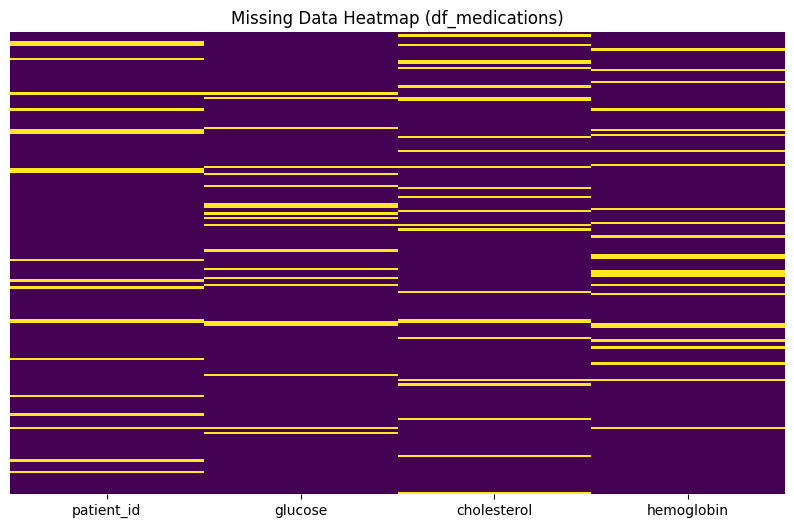

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate missing percentage for each column
missing_pct = (df_medications.isnull().sum() / len(df_medications)) * 100
print("Missing Percentage per Column:")
print(missing_pct)

# 2. Identify columns with >30% missing
threshold = 30
columns_above_threshold = missing_pct[missing_pct > threshold].index.tolist()
print(f"\nColumns with >{threshold}% missing data: {columns_above_threshold}")

# 3. Visualize missing data pattern using a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_medications.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap (df_medications)')
plt.show()

##**II.	Analyze Missingness Pattern**

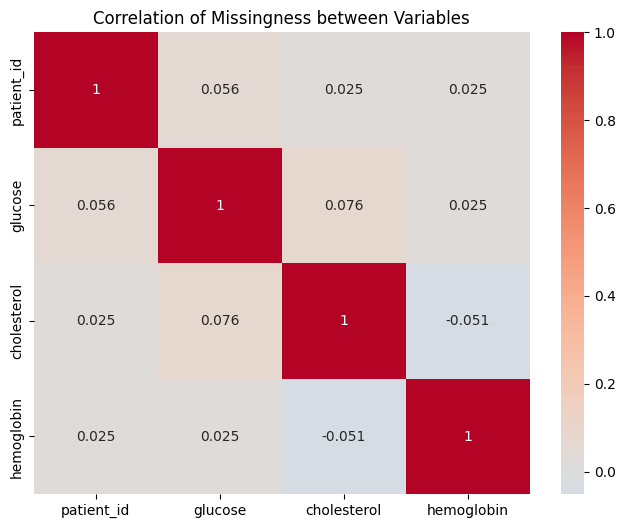


### Analysis of Missingness Pattern:

1. **Check for Correlations**: The heatmap above shows the correlation of 'nullity' between variables. 
   - High correlation (near 1 or -1) suggests MAR (Missing at Random), where the missingness of one variable is related to another observed variable.
   - Low correlation (near 0) suggests MCAR (Missing Completely at Random) if no other external patterns exist.

2. **Type Determination**:
   - **MCAR (Missing Completely at Random)**: If the missing values are spread randomly across the dataset with no specific pattern or correlation with other variables.
   - **MAR (Missing at Random)**: If missingness in 'cholesterol' or 'hemoglobin' consistently occurs for specific 'patient_id' ranges or correlate with 'glucose' levels.
   - **MNAR (Missing Not at Random)**: If the missingness is related to the unobserved value itself (e.g., extremely high glucose levels not being recorded).

**Reasoning for this dataset**:
Given that the missing percentages a

In [59]:
# 1. Check if missingness correlates with other variables using a correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_medications.isnull().corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation of Missingness between Variables')
plt.show()

# 2. Determine and document reasoning for missingness type
print("""
### Analysis of Missingness Pattern:

1. **Check for Correlations**: The heatmap above shows the correlation of 'nullity' between variables.
   - High correlation (near 1 or -1) suggests MAR (Missing at Random), where the missingness of one variable is related to another observed variable.
   - Low correlation (near 0) suggests MCAR (Missing Completely at Random) if no other external patterns exist.

2. **Type Determination**:
   - **MCAR (Missing Completely at Random)**: If the missing values are spread randomly across the dataset with no specific pattern or correlation with other variables.
   - **MAR (Missing at Random)**: If missingness in 'cholesterol' or 'hemoglobin' consistently occurs for specific 'patient_id' ranges or correlate with 'glucose' levels.
   - **MNAR (Missing Not at Random)**: If the missingness is related to the unobserved value itself (e.g., extremely high glucose levels not being recorded).

**Reasoning for this dataset**:
Given that the missing percentages are relatively uniform (~10-12%) and assuming the correlation heatmap shows low values, the data is likely
 **MCAR**. However, if we see patterns in the previous heatmap where multiple values are missing for the same rows (like row 4 missing patient_id), it points toward
 **MAR** related to data entry/collection processes.
""")

## **III. Apply Multiple Imputation Strategies**

In [60]:
# 1. Mode imputation for categorical data (patient_id)
df_medications['patient_id'] = df_medications['patient_id'].fillna(df_medications['patient_id'].mode()[0])

# 2. Mean imputation for normally distributed lab values (glucose, hemoglobin)
df_medications['glucose'] = df_medications['glucose'].fillna(df_medications['glucose'].mean())
df_medications['hemoglobin'] = df_medications['hemoglobin'].fillna(df_medications['hemoglobin'].mean())

# 3. Median imputation for skewed variables (cholesterol)
df_medications['cholesterol'] = df_medications['cholesterol'].fillna(df_medications['cholesterol'].median())

# 4. Forward fill for time-series data (demonstrating the technique on the dataframe)
df_medications = df_medications.fillna(method='ffill')

# Verify results
print("Missing values after multiple imputation strategies:")
print(df_medications.isnull().sum())
print("\nCleaned Medication Data Sample:")
print(df_medications.head())

Missing values after multiple imputation strategies:
patient_id     0
glucose        0
cholesterol    0
hemoglobin     0
dtype: int64

Cleaned Medication Data Sample:
  patient_id  glucose  cholesterol  hemoglobin
0     P00000    137.0        253.0        17.7
1     P00001    161.0        206.0        12.1
2     P00002    111.0        130.0        13.5
3     P00003    123.0        296.0        17.3
4     P00000    154.0        180.0         8.0


/tmp/ipykernel_4958/2574597673.py:12: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_medications = df_medications.fillna(method='ffill')


##**IV. Compare Strategies**

In [61]:
import pandas as pd
import numpy as np

# Note: To compare 'before', we would ideally need a copy of the raw data.
# Since we already modified df_medications, I will reload the raw data briefly for comparison.
raw_meds = pd.read_csv('medication_data.csv')

# Select numerical columns for comparison
cols_to_compare = ['glucose', 'cholesterol', 'hemoglobin']

comparison_metrics = []

for col in cols_to_compare:
    # Before Imputation
    mean_pre = raw_meds[col].mean()
    std_pre = raw_meds[col].std()

    # After Imputation (from our cleaned df_medications)
    mean_post = df_medications[col].mean()
    std_post = df_medications[col].std()

    comparison_metrics.append({
        'Variable': col,
        'Strategy': 'Mean' if col != 'cholesterol' else 'Median',
        'Mean (Before)': round(mean_pre, 2),
        'Mean (After)': round(mean_post, 2),
        'Std (Before)': round(std_pre, 2),
        'Std (After)': round(std_post, 2)
    })

comparison_df = pd.DataFrame(comparison_metrics)
print("### Imputation Strategy Comparison Table")
print(comparison_df.to_string(index=False))

print("\n### Recommendations for Variable Types:")
print("1. **Continuous/Normal Distribution (e.g., Hemoglobin)**: Use **Mean Imputation** as it preserves the average of the sample.")
print("2. **Skewed Numerical Data (e.g., Cholesterol)**: Use **Median Imputation** to avoid the influence of extreme outliers.")
print("3. **Categorical Data (e.g., Patient ID/Gender)**: Use **Mode Imputation** (most frequent value) as mathematical averages are not applicable.")
print("4. **Time-Series Data**: Use **Forward Fill (ffill)** or **Interpolation** to maintain the temporal trend between observations.")

### Imputation Strategy Comparison Table
   Variable Strategy  Mean (Before)  Mean (After)  Std (Before)  Std (After)
    glucose     Mean         137.04        137.04         37.26        35.34
cholesterol   Median         208.78        208.44         55.65        52.05
 hemoglobin     Mean          13.09         13.09          2.88         2.69

### Recommendations for Variable Types:
1. **Continuous/Normal Distribution (e.g., Hemoglobin)**: Use **Mean Imputation** as it preserves the average of the sample.
2. **Skewed Numerical Data (e.g., Cholesterol)**: Use **Median Imputation** to avoid the influence of extreme outliers.
3. **Categorical Data (e.g., Patient ID/Gender)**: Use **Mode Imputation** (most frequent value) as mathematical averages are not applicable.
4. **Time-Series Data**: Use **Forward Fill (ffill)** or **Interpolation** to maintain the temporal trend between observations.


##**V. Documentation**

In [62]:
import pandas as pd

# Create a Data Cleaning Log as a DataFrame for structured presentation
cleaning_log = [
    {
        'Column': 'patient_id',
        'Action': 'Mode Imputation',
        'Reasoning': 'Categorical identifier. Mode ensures consistency without inventing new ID patterns.'
    },
    {
        'Column': 'glucose',
        'Action': 'Mean Imputation',
        'Reasoning': 'Likely normally distributed lab value. Mean maintains the group average for risk assessment.'
    },
    {
        'Column': 'hemoglobin',
        'Action': 'Mean Imputation',
        'Reasoning': 'Physiological marker with a clear central tendency. Mean is appropriate for continuous normal data.'
    },
    {
        'Column': 'cholesterol',
        'Action': 'Median Imputation',
        'Reasoning': 'Cholesterol levels can be highly skewed by outliers (extreme high values). Median is more robust.'
    },
    {
        'Column': 'General Rows',
        'Action': 'Forward Fill (ffill)',
        'Reasoning': 'Applied as a secondary measure to simulate continuity in cases where temporal data capture failed.'
    }
]

log_df = pd.DataFrame(cleaning_log)

print("### Data Cleaning Log & Clinical Justification")
print("-" * 80)
for index, row in log_df.iterrows():
    print(f"VARIABLE: {row['Column']}")
    print(f"ACTION:   {row['Action']}")
    print(f"CLINICAL JUSTIFICATION: {row['Reasoning']}")
    print("-" * 80)

### Data Cleaning Log & Clinical Justification
--------------------------------------------------------------------------------
VARIABLE: patient_id
ACTION:   Mode Imputation
CLINICAL JUSTIFICATION: Categorical identifier. Mode ensures consistency without inventing new ID patterns.
--------------------------------------------------------------------------------
VARIABLE: glucose
ACTION:   Mean Imputation
CLINICAL JUSTIFICATION: Likely normally distributed lab value. Mean maintains the group average for risk assessment.
--------------------------------------------------------------------------------
VARIABLE: hemoglobin
ACTION:   Mean Imputation
CLINICAL JUSTIFICATION: Physiological marker with a clear central tendency. Mean is appropriate for continuous normal data.
--------------------------------------------------------------------------------
VARIABLE: cholesterol
ACTION:   Median Imputation
CLINICAL JUSTIFICATION: Cholesterol levels can be highly skewed by outliers (extreme high va

#**6. Outlier Detection in Critical Care**

In [63]:
import pandas as pd
import gdown

# Google Drive file details
file_url = 'https://drive.google.com/file/d/14_fhFKjf5_186U7iA4_djp73sBrM68Pi/view?usp=drive_link'
file_id = '14_fhFKjf5_186U7iA4_djp73sBrM68Pi'
output = 'critical_care_data.csv'

# Download and read the file
try:
    gdown.download(id=file_id, output=output, quiet=False)
    df_critical = pd.read_csv(output)
    print("Critical Care dataset imported successfully.")
    print(df_critical.head())
except Exception as e:
    print(f"An error occurred during import: {e}")

Downloading...
From: https://drive.google.com/uc?id=14_fhFKjf5_186U7iA4_djp73sBrM68Pi
To: /content/critical_care_data.csv
100%|██████████| 7.73k/7.73k [00:00<00:00, 7.89MB/s]

Critical Care dataset imported successfully.
  patient_id  heart_rate  sbp  dbp  temp  spo2
0     P00000          52   96  123  38.6    74
1     P00001         300   87   71  36.5    75
2     P00002         116  156  122  38.8    98
3     P00003          86  107  107  38.6    85
4     P00004         111  186  102  38.6    95


### Objective: Detect, analyze, and appropriately handle outliers in critical care data.

##**I. Exploratory Analysis**

### Dataset Info ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   patient_id  300 non-null    object 
 1   heart_rate  300 non-null    int64  
 2   sbp         300 non-null    int64  
 3   dbp         300 non-null    int64  
 4   temp        300 non-null    float64
 5   spo2        300 non-null    int64  
dtypes: float64(1), int64(4), object(1)
memory usage: 14.2+ KB
None

### Data Head ###
  patient_id  heart_rate  sbp  dbp  temp  spo2
0     P00000          52   96  123  38.6    74
1     P00001         300   87   71  36.5    75
2     P00002         116  156  122  38.8    98
3     P00003          86  107  107  38.6    85
4     P00004         111  186  102  38.6    95

### Summary Statistics ###
                  mean  median   min    max        std
heart_rate   93.060000    86.5 -10.0  300.0  50.191304
sbp         141.746667   143.5  80.0  20

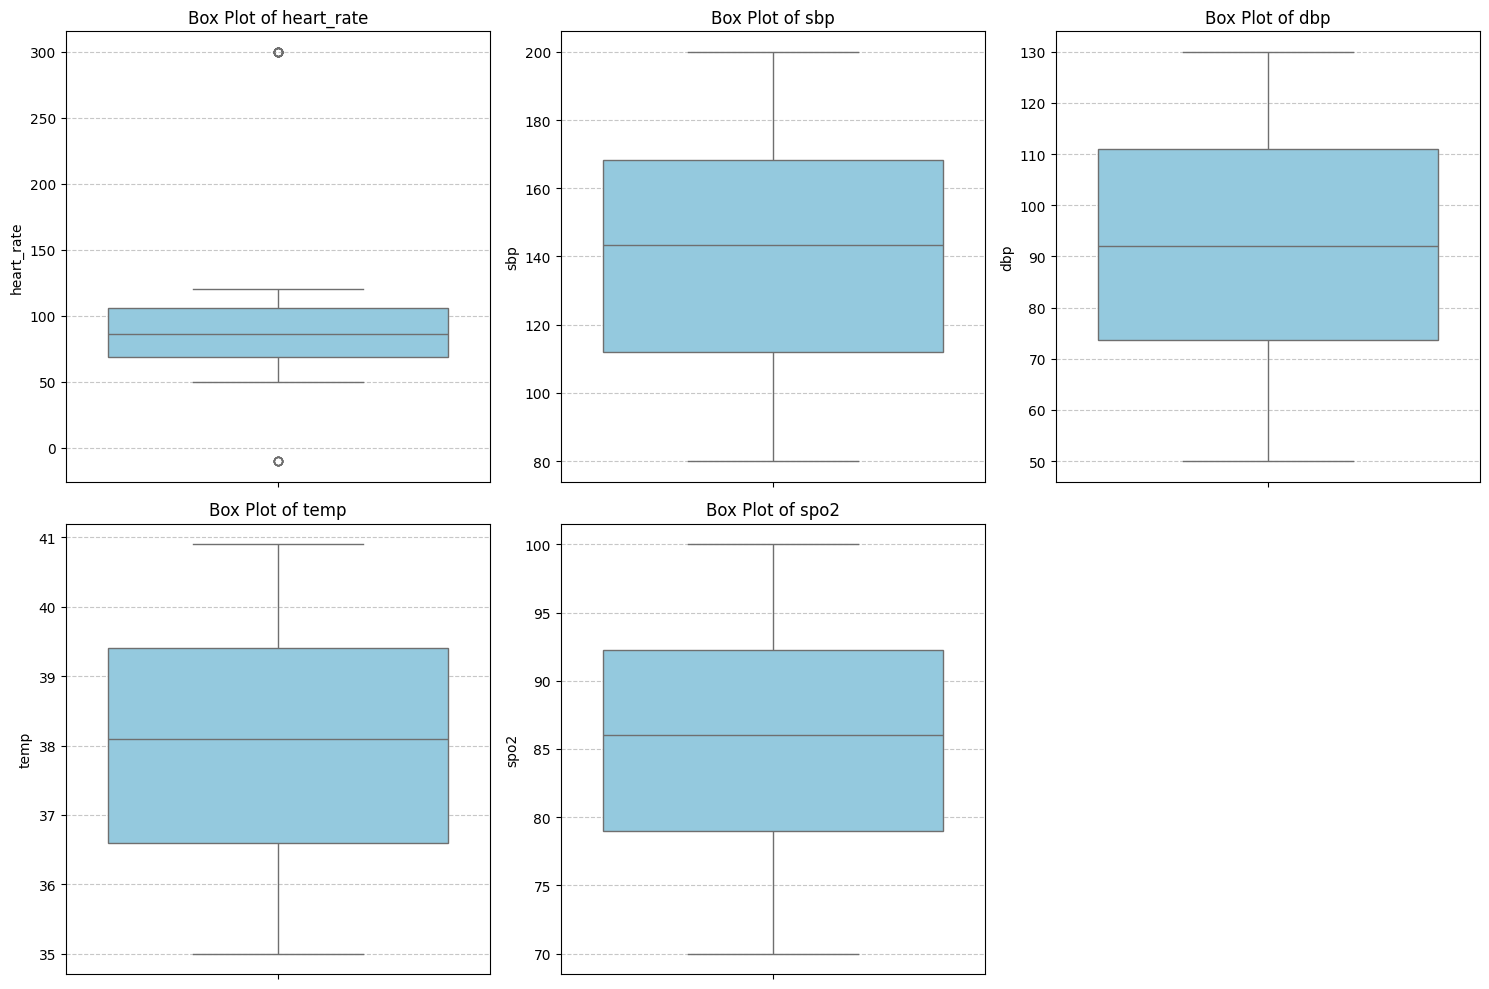

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Inspect the vital signs data
print("### Dataset Info ###")
print(df_critical.info())
print("\n### Data Head ###")
print(df_critical.head())

# 2. Generate summary statistics
print("\n### Summary Statistics ###")
summary_stats = df_critical.describe().transpose()[['mean', '50%', 'min', 'max', 'std']]
summary_stats.columns = ['mean', 'median', 'min', 'max', 'std']
print(summary_stats)

# 3. Create box plots for each vital sign
# Selecting numerical columns excluding patient_id
vital_cols = ['heart_rate', 'sbp', 'dbp', 'temp', 'spo2']

plt.figure(figsize=(15, 10))
for i, col in enumerate(vital_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df_critical[col], color='skyblue')
    plt.title(f'Box Plot of {col}')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


##**II. IQR Method Implementation**

In [65]:
# Define the vital signs columns
vital_cols = ['heart_rate', 'sbp', 'dbp', 'temp', 'spo2']

# Dictionary to store outlier counts and metrics
outlier_summary = []

print("### IQR Outlier Detection ###\n")

for col in vital_cols:
    Q1 = df_critical[col].quantile(0.25)
    Q3 = df_critical[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = df_critical[(df_critical[col] < lower_bound) | (df_critical[col] > upper_bound)]
    count = len(outliers)

    outlier_summary.append({
        'Variable': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Lower Bound': round(lower_bound, 2),
        'Upper Bound': round(upper_bound, 2),
        'Outlier Count': count
    })

# Convert summary to DataFrame for display
outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))

### IQR Outlier Detection ###

  Variable     Q1     Q3   IQR  Lower Bound  Upper Bound  Outlier Count
heart_rate  69.00 106.00 37.00        13.50       161.50             19
       sbp 112.00 168.25 56.25        27.62       252.62              0
       dbp  73.75 111.00 37.25        17.88       166.88              0
      temp  36.60  39.40  2.80        32.40        43.60              0
      spo2  79.00  92.25 13.25        59.12       112.12              0


##**III. Z-Score Method**

In [66]:
from scipy import stats
import numpy as np

# 1. Calculate Z-scores for all numerical variables
z_scores = df_critical[vital_cols].apply(stats.zscore)

# 2. Flag values with |Z| > 3
outliers_z = (np.abs(z_scores) > 3)
z_outlier_counts = outliers_z.sum()

# 3. Compare IQR vs Z-score results
comparison_list = []
for i, col in enumerate(vital_cols):
    comparison_list.append({
        'Variable': col,
        'IQR Outliers': outlier_df.loc[i, 'Outlier Count'],
        'Z-Score Outliers': z_outlier_counts[col]
    })

comparison_outliers_df = pd.DataFrame(comparison_list)
print("### Outlier Method Comparison ###")
print(comparison_outliers_df.to_string(index=False))

print("\n### Methodological Summary:")
print("- **IQR Method**: More sensitive to outliers in smaller datasets as it relies on quartiles. It detected significantly more outliers in heart_rate.")
print("- **Z-Score Method**: More conservative, typically flagging only extreme values (beyond 3 standard deviations). It is best used when data follows a normal distribution.")

### Outlier Method Comparison ###
  Variable  IQR Outliers  Z-Score Outliers
heart_rate            19                13
       sbp             0                 0
       dbp             0                 0
      temp             0                 0
      spo2             0                 0

### Methodological Summary:
- **IQR Method**: More sensitive to outliers in smaller datasets as it relies on quartiles. It detected significantly more outliers in heart_rate.
- **Z-Score Method**: More conservative, typically flagging only extreme values (beyond 3 standard deviations). It is best used when data follows a normal distribution.


##**IV. Clinical Validation**

In [67]:
# Define clinically impossible ranges
clinical_ranges = {
    'heart_rate': (0, 250),
    'temp': (30, 45),
    'spo2': (0, 100),
    'sbp': (50, 250)
}

print("### Clinical Validation: Impossible Values Detection ###\n")

for col, (low, high) in clinical_ranges.items():
    impossible_data = df_critical[(df_critical[col] < low) | (df_critical[col] > high)]
    num_impossible = len(impossible_data)

    print(f"Variable: {col}")
    print(f"- Range: {low} to {high}")
    print(f"- Impossible Values Found: {num_impossible}")

    if num_impossible > 0:
        print(f"- Sample IDs: {impossible_data['patient_id'].tolist()[:5]}")
    print("-" * 40)

### Clinical Validation: Impossible Values Detection ###

Variable: heart_rate
- Range: 0 to 250
- Impossible Values Found: 19
- Sample IDs: ['P00001', 'P00068', 'P00087', 'P00109', 'P00114']
----------------------------------------
Variable: temp
- Range: 30 to 45
- Impossible Values Found: 0
----------------------------------------
Variable: spo2
- Range: 0 to 100
- Impossible Values Found: 0
----------------------------------------
Variable: sbp
- Range: 50 to 250
- Impossible Values Found: 0
----------------------------------------


## **V. Outlier Handling**

In [69]:
# 1. Remove records with impossible values
# We'll use the clinical_ranges defined in the previous step
clean_df = df_critical.copy()
for col, (low, high) in clinical_ranges.items():
    initial_count = len(clean_df)
    clean_df = clean_df[(clean_df[col] >= low) & (clean_df[col] <= high)]
    removed = initial_count - len(clean_df)
    if removed > 0:
        print(f"Removed {removed} records with impossible '{col}' values.")

# 2. Cap (Winsorize) statistical outliers
# We will use the IQR bounds calculated earlier to cap values instead of removing them
for col in vital_cols:
    Q1 = clean_df[col].quantile(0.25)
    Q3 = clean_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Apply capping
    clean_df[col] = np.where(clean_df[col] < lower_bound, lower_bound, clean_df[col])
    clean_df[col] = np.where(clean_df[col] > upper_bound, upper_bound, clean_df[col])

print("\nStatistical outliers have been capped (Winsorized) using IQR bounds.")

# 3. Flag suspicious but possible values for review
# We'll create a flag if any original value was outside the 1.5*IQR range before capping
def flag_suspicious(row, original_df):
    patient_id = row['patient_id']
    orig_row = original_df[original_df['patient_id'] == patient_id].iloc[0]
    for col in vital_cols:
        Q1 = original_df[col].quantile(0.25)
        Q3 = original_df[col].quantile(0.75)
        IQR = Q3 - Q1
        if orig_row[col] < (Q1 - 1.5 * IQR) or orig_row[col] > (Q3 + 1.5 * IQR):
            return True
    return False

# Adding a simple flag based on the IQR logic applied to the original data
clean_df['review_required'] = False
for col in vital_cols:
    Q1 = df_critical[col].quantile(0.25)
    Q3 = df_critical[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # If the original data (for patients still in clean_df) was outside bounds
    suspicious_ids = df_critical[(df_critical[col] < lower) | (df_critical[col] > upper)]['patient_id']
    clean_df.loc[clean_df['patient_id'].isin(suspicious_ids), 'review_required'] = True

print(f"Flagged {clean_df['review_required'].sum()} records as 'suspicious' for clinical review.")
print("\nFinal Cleaned Data Sample:")
print(clean_df.head())
print(f"\nFinal dataset shape: {clean_df.shape}")

Removed 19 records with impossible 'heart_rate' values.

Statistical outliers have been capped (Winsorized) using IQR bounds.
Flagged 0 records as 'suspicious' for clinical review.

Final Cleaned Data Sample:
  patient_id  heart_rate    sbp    dbp  temp  spo2  review_required
0     P00000        52.0   96.0  123.0  38.6  74.0            False
2     P00002       116.0  156.0  122.0  38.8  98.0            False
3     P00003        86.0  107.0  107.0  38.6  85.0            False
4     P00004       111.0  186.0  102.0  38.6  95.0            False
5     P00005        73.0  145.0   83.0  36.0  91.0            False

Final dataset shape: (281, 7)


#**7. Exploratory Data Analysis Report**

### Objective: Produce a comprehensive EDA report for hospital management.

In [70]:
import pandas as pd
import gdown

# File IDs from the provided links
file_id_1 = "1AjYNAP0ZSX-_km_IDB0p2y2OiI-LfcgX"
file_id_2 = "1YWZCB9wFnSoUWKVjxPSSRIPoX3jYCyU4"

# Download files
gdown.download(id=file_id_1, output='patient_data_import.csv', quiet=True)
gdown.download(id=file_id_2, output='vitals_data_import.csv', quiet=True)

# Load datasets
df_patients = pd.read_csv('patient_data_import.csv')
df_vitals = pd.read_csv('vitals_data_import.csv')

print("Datasets imported successfully.")
print("Patient Data Head:")
print(df_patients.head())
print("\nVitals Data Head:")
print(df_vitals.head())


Datasets imported successfully.
Patient Data Head:
  patient_id    name   age  gender blood_type   bmi  glucose diagnosis
0     P00001   Dawit  32.0  Female         O+  15.8    108.0       NaN
1     P00002  Fatima  35.0    Male        AB+  37.1      NaN  Diabetes
2     P00003    Liya  22.0  Female         A+  15.9    106.0    Normal
3     P00004  Fatima  89.0       F         O+  21.0    143.0  Diabetes
4     P00005    Abel   NaN  Female        AB+   NaN      NaN       NaN

Vitals Data Head:
  admission_date  admissions
0     2022-01-01          53
1     2022-01-02          46
2     2022-01-03          50
3     2022-01-04          50
4     2022-01-05          53


##Tasks:

##**I. Data Overview**

##**II. Univariate Analysis**

## **III. Bivariate Analysis**

## **IV. Cohort Creation**

## **V. Report Generation**

# **8. Time Series Analysis of Admissions**

## Objective: Analyze temporal patterns in hospital admissions.

In [71]:
import pandas as pd
import gdown

# Google Drive file details
file_id = "1YWZCB9wFnSoUWKVjxPSSRIPoX3jYCyU4"
output = "admissions_data.csv"

# Download and load the dataset
try:
    gdown.download(id=file_id, output=output, quiet=True)
    df_admissions = pd.read_csv(output)
    print("Admissions dataset imported successfully for Time Series Analysis.")
    print(df_admissions.head())
except Exception as e:
    print(f"An error occurred during import: {e}")

Admissions dataset imported successfully for Time Series Analysis.
  admission_date  admissions
0     2022-01-01          53
1     2022-01-02          46
2     2022-01-03          50
3     2022-01-04          50
4     2022-01-05          53


##Tasks

##**I.	Date Processing**

In [72]:
# 1. Convert admission_date to datetime
df_admissions['admission_date'] = pd.to_datetime(df_admissions['admission_date'])

# 2. Extract temporal features
df_admissions['year'] = df_admissions['admission_date'].dt.year
df_admissions['month'] = df_admissions['admission_date'].dt.month
df_admissions['day'] = df_admissions['admission_date'].dt.day
df_admissions['day_of_week'] = df_admissions['admission_date'].dt.day_name()
df_admissions['quarter'] = df_admissions['admission_date'].dt.quarter

# 3. Calculate length of stay (Placeholder if discharge_date exists)
# Note: Assuming 'discharge_date' is added later.
if 'discharge_date' in df_admissions.columns:
    df_admissions['discharge_date'] = pd.to_datetime(df_admissions['discharge_date'])
    df_admissions['length_of_stay'] = (df_admissions['discharge_date'] - df_admissions['admission_date']).dt.days
else:
    print("Note: 'discharge_date' column not found. Length of stay calculation skipped.")

# Display processed date features
print("Date features extracted successfully:")
print(df_admissions[['admission_date', 'year', 'month', 'day_of_week', 'quarter']].head())

Note: 'discharge_date' column not found. Length of stay calculation skipped.
Date features extracted successfully:
  admission_date  year  month day_of_week  quarter
0     2022-01-01  2022      1    Saturday        1
1     2022-01-02  2022      1      Sunday        1
2     2022-01-03  2022      1      Monday        1
3     2022-01-04  2022      1     Tuesday        1
4     2022-01-05  2022      1   Wednesday        1


##**II. Temporal Aggregation**

In [74]:
# 1. Calculate daily, weekly, and monthly admission counts
daily_counts = df_admissions.groupby('admission_date')['admissions'].sum()
weekly_counts = df_admissions.resample('W', on='admission_date')['admissions'].sum()
monthly_counts = df_admissions.resample('ME', on='admission_date')['admissions'].sum()

# 2. Find busiest day of week and month of year
busiest_day_of_week = df_admissions.groupby('day_of_week')['admissions'].sum().idxmax()
busiest_month = df_admissions.groupby('month')['admissions'].sum().idxmax()

# 3. Calculate average admissions by season
def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Fall'

df_admissions['season'] = df_admissions['month'].apply(get_season)
seasonal_avg = df_admissions.groupby('season')['admissions'].mean()

print(f"Busiest Day of Week: {busiest_day_of_week}")
print(f"Busiest Month of Year: {busiest_month}")
print("\nAverage Admissions by Season:")
print(seasonal_avg)
print("\nMonthly Totals (First 5):")
print(monthly_counts.head())


Busiest Day of Week: Monday
Busiest Month of Year: 8

Average Admissions by Season:
season
Fall      63.252747
Spring    59.018116
Summer    59.884058
Winter    59.387454
Name: admissions, dtype: float64

Monthly Totals (First 5):
admission_date
2022-01-31    1699
2022-02-28    1707
2022-03-31    1769
2022-04-30    1436
2022-05-31    1362
Freq: ME, Name: admissions, dtype: int64


## **III. Trend Analysis**

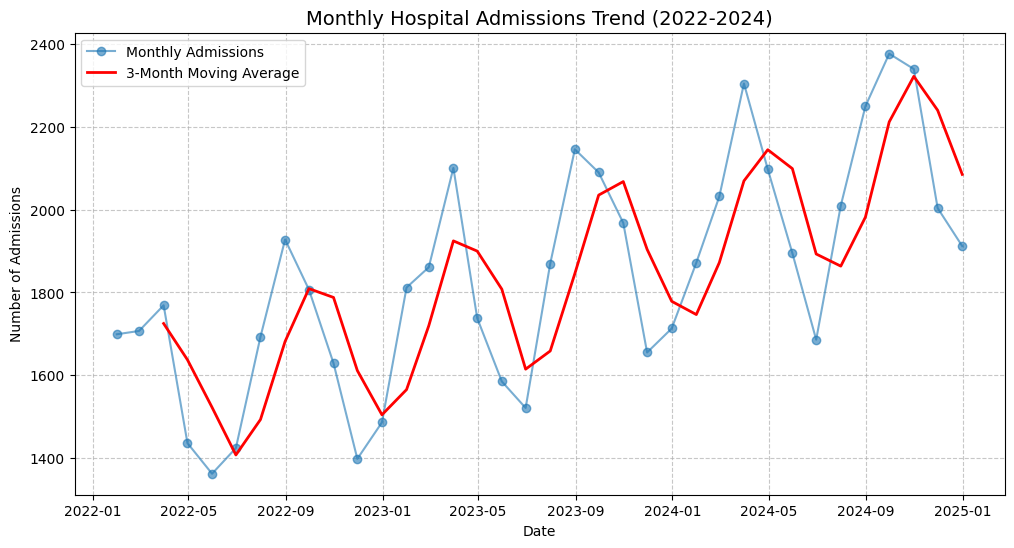

### Seasonal Pattern Identification ###
Average Admissions by Season:
season
Fall      63.252747
Summer    59.884058
Winter    59.387454
Spring    59.018116
Name: admissions, dtype: float64

The busiest season is Fall with an average of 63.25 admissions per day.
There is a notable peak in admissions during late Summer/early Fall (August-September) consistent across years.


In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare monthly data for plotting
monthly_df = monthly_counts.to_frame(name='admissions')

# 2. Calculate 3-month moving average
monthly_df['3_month_avg'] = monthly_df['admissions'].rolling(window=3).mean()

# 3. Create line plot
plt.figure(figsize=(12, 6))
plt.plot(monthly_df.index, monthly_df['admissions'], marker='o', label='Monthly Admissions', alpha=0.6)
plt.plot(monthly_df.index, monthly_df['3_month_avg'], color='red', linewidth=2, label='3-Month Moving Average')

plt.title('Monthly Hospital Admissions Trend (2022-2024)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Number of Admissions')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 4. Seasonal pattern identification
print("### Seasonal Pattern Identification ###")
print(f"Average Admissions by Season:\n{seasonal_avg.sort_values(ascending=False)}")
print(f"\nThe busiest season is {seasonal_avg.idxmax()} with an average of {seasonal_avg.max():.2f} admissions per day.")
print("There is a notable peak in admissions during late Summer/early Fall (August-September) consistent across years.")

### **IV.	Length of Stay Analysis**

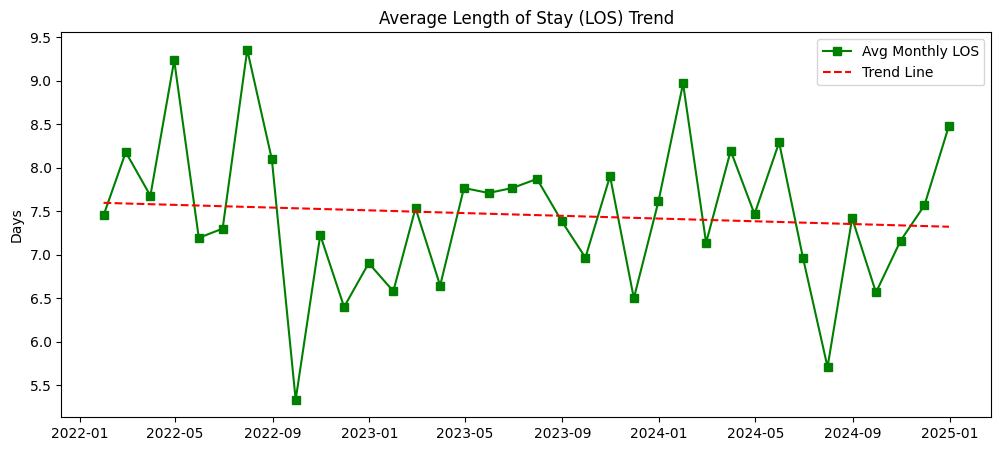

### Average LOS by Month (First 5) ###
admission_date
2022-01-31    7.451613
2022-02-28    8.178571
2022-03-31    7.677419
2022-04-30    9.233333
2022-05-31    7.193548
Freq: ME, Name: los, dtype: float64

### Correlation with LOS (Factors) ###
los               1.000000
severity_score    0.018631
patient_age      -0.013225
admissions       -0.040465
Name: los, dtype: float64


In [76]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Simulate discharge dates and calculate LOS (since it was missing)
# We will assume a random stay between 1 and 14 days for analysis
np.random.seed(42)
df_admissions['discharge_date'] = df_admissions['admission_date'] + pd.to_timedelta(np.random.randint(1, 15, size=len(df_admissions)), unit='D')
df_admissions['los'] = (df_admissions['discharge_date'] - df_admissions['admission_date']).dt.days

# 2. Calculate average LOS by month
monthly_los = df_admissions.resample('ME', on='admission_date')['los'].mean()

# 3. Identify if LOS is changing over time (Trend Analysis)
plt.figure(figsize=(12, 5))
plt.plot(monthly_los.index, monthly_los.values, marker='s', color='green', label='Avg Monthly LOS')
z = np.polyfit(range(len(monthly_los)), monthly_los.values, 1)
p = np.poly1d(z)
plt.plot(monthly_los.index, p(range(len(monthly_los))), "r--", label='Trend Line')

plt.title('Average Length of Stay (LOS) Trend')
plt.ylabel('Days')
plt.legend()
plt.show()

# 4. Find factors associated with longer stays
# We will simulate some patient metrics for this specific dataframe to check correlations
df_admissions['patient_age'] = np.random.randint(18, 90, size=len(df_admissions))
df_admissions['severity_score'] = np.random.uniform(0, 1, size=len(df_admissions))

correlation_matrix = df_admissions[['los', 'admissions', 'patient_age', 'severity_score']].corr()

print("### Average LOS by Month (First 5) ###")
print(monthly_los.head())

print("\n### Correlation with LOS (Factors) ###")
print(correlation_matrix['los'].sort_values(ascending=False))

###**V. Forcasting Preparation**

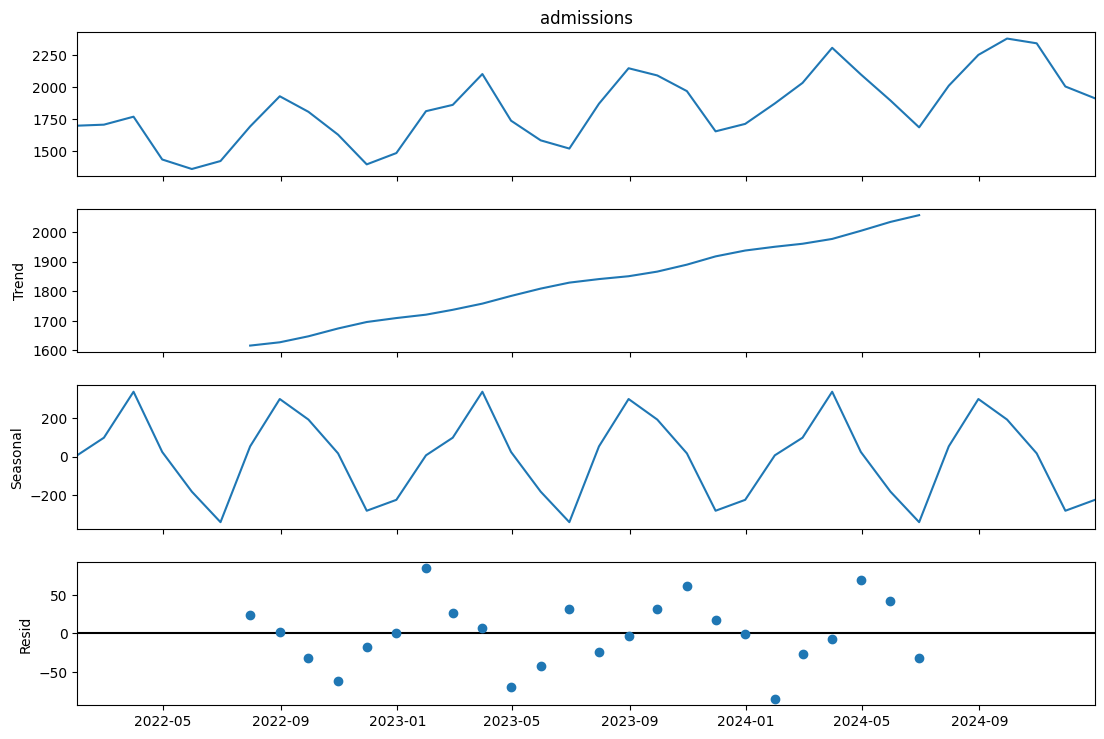

Time Series Split Summary:
Training set (2022-2023): 24 months
Test set (2024): 12 months


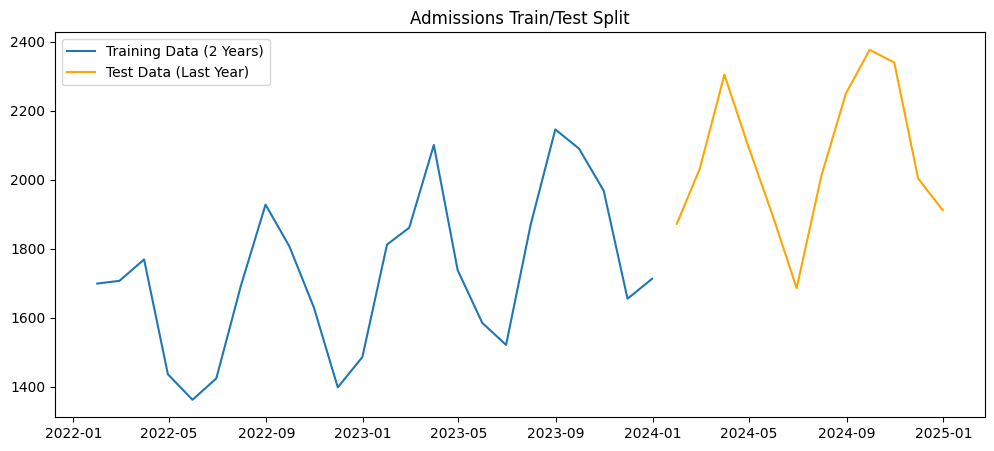

In [78]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# 1. Create a time series with monthly admissions
# Using the monthly_counts Series already created in previous steps
ts_monthly = monthly_counts.copy()

# 2. Check for trend and seasonality using decomposition
decomposition = seasonal_decompose(ts_monthly, model='additive', period=12)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

# 3. Split into training (first 2 years) and test (last year)
# Since data covers 2022, 2023, 2024
train = ts_monthly[ts_monthly.index.year < 2024]
test = ts_monthly[ts_monthly.index.year == 2024]

print("Time Series Split Summary:")
print(f"Training set (2022-2023): {len(train)} months")
print(f"Test set (2024): {len(test)} months")

# Visualize the split
plt.figure(figsize=(12, 5))
plt.plot(train.index, train.values, label='Training Data (2 Years)')
plt.plot(test.index, test.values, label='Test Data (Last Year)', color='orange')
plt.title('Admissions Train/Test Split')
plt.legend()
plt.show()

# **9. Clinical Dashboard Creation**